# **1-Load Needed Libraries and Preproccessing**

---



---



In [1]:
import kagglehub

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score)
import shap

path = kagglehub.dataset_download("brandao/diabetes")
print("Path to dataset files:", path)

import os
file_path = os.path.join(path, [f for f in os.listdir(path) if f.endswith('.csv')][0])
df = pd.read_csv(file_path)

print("Original dataset shape:", df.shape)
df

Using Colab cache for faster access to the 'diabetes' dataset.
Path to dataset files: /kaggle/input/diabetes
Original dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [2]:
df["weight"].value_counts()

,count
weight,
?,98569
[75-100),1336
[50-75),897
[100-125),625
[125-150),145
[25-50),97
[0-25),48
[150-175),35
[175-200),11


In [3]:
df["payer_code"].value_counts()

,count
payer_code,
?,40256
MC,32439
HM,6274
SP,5007
BC,4655
MD,3532
CP,2533
UN,2448
CM,1937


In [4]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [5]:
df = df[df['race'] != '?']
df = df[df['gender'] != 'Unknown/Invalid']

In [6]:
def map_discharge(x):
    if x == 1:
        return "Home"
    elif x in [3, 6]:
        return "Care"
    elif x == 2:
        return "Transfer"
    elif x in [11, 19, 20, 21]:
        return "Death"
    elif x in [13, 14]:
        return "Hospice"
    elif x == 18:
        return "Unknown"
    else:
        return "Other"

df['discharge_group'] = df['discharge_disposition_id'].apply(map_discharge)
df = df[df['discharge_group'] != 'Unknown']

In [7]:
df_c = df.drop(columns=[
    'discharge_disposition_id',
    'metformin-pioglitazone',
    'glyburide-metformin',
    'glimepiride-pioglitazone',
    'encounter_id',
    'patient_nbr',
    'weight',
    'max_glu_serum',
    'A1Cresult',
    'payer_code',
    'medical_specialty',
    'glipizide-metformin',
    'metformin-rosiglitazone',
    'examide',
    'citoglipton',
    'acetohexamide',
    'troglitazone',
    'tolbutamide',
    'tolazamide',
    'chlorpropamide', 'miglitol', 'acarbose',
    'nateglinide', 'repaglinide'
])

df_c.shape

(95819, 27)

In [8]:
def map_icd9(code):
    try:
        c = str(code).strip()
        if c.startswith('V'): return 'Supplementary'
        if c.startswith('E'): return 'External_Causes'
        n = float(c)
        if n < 140:  return 'Infectious'
        if n < 240:  return 'Neoplasms'
        if n < 280:  return 'Endocrine_Diabetes'
        if n < 290:  return 'Blood'
        if n < 320:  return 'Mental'
        if n < 360:  return 'Nervous_System'
        if n < 390:  return 'Sensory'
        if n < 460:  return 'Circulatory'
        if n < 520:  return 'Respiratory'
        if n < 580:  return 'Digestive'
        if n < 630:  return 'Genitourinary'
        if n < 680:  return 'Pregnancy'
        if n < 710:  return 'Skin'
        if n < 740:  return 'Musculoskeletal'
        if n < 760:  return 'Congenital'
        if n < 780:  return 'Perinatal'
        if n < 800:  return 'Symptoms'
        return 'Injury'
    except:
        return 'Other'

df_c['diag_1'] = df_c['diag_1'].apply(map_icd9)
df_c['diag_2'] = df_c['diag_2'].apply(map_icd9)
df_c['diag_3'] = df_c['diag_3'].apply(map_icd9)

In [9]:
df_c.isnull().sum().sum()
df_c.duplicated().sum()
df_c.drop_duplicates(inplace=True)

In [10]:


# 0 → Will not return
# 1 → Will return after a long time
# 2 → Will return soon (dangerous)
readmit_map = {'NO': 0, '>30': 1, '<30': 2}
df_c['readmitted'] = df_c['readmitted'].map(readmit_map)

df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95818 entries, 0 to 101765
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   race                 95818 non-null  object
 1   gender               95818 non-null  object
 2   age                  95818 non-null  object
 3   admission_type_id    95818 non-null  int64 
 4   admission_source_id  95818 non-null  int64 
 5   time_in_hospital     95818 non-null  int64 
 6   num_lab_procedures   95818 non-null  int64 
 7   num_procedures       95818 non-null  int64 
 8   num_medications      95818 non-null  int64 
 9   number_outpatient    95818 non-null  int64 
 10  number_emergency     95818 non-null  int64 
 11  number_inpatient     95818 non-null  int64 
 12  diag_1               95818 non-null  object
 13  diag_2               95818 non-null  object
 14  diag_3               95818 non-null  object
 15  number_diagnoses     95818 non-null  int64 
 16  metformi

In [11]:
df_num = df_c.select_dtypes(include=np.number)

#**Step 2: EDA**
----------------------------------------------------------------------------------------------
------------------------------------------------------------------------


/tmp/ipykernel_2067/3298773600.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_c, x='readmitted', palette='spring')
/tmp/ipykernel_2067/3298773600.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Readmit', '>30 Days', '<30 Days'])


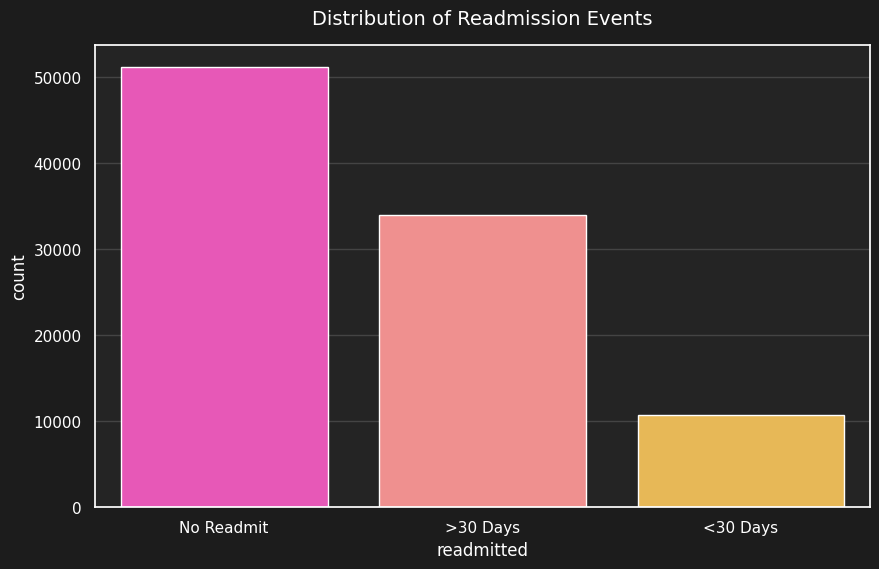

In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_c, x='readmitted', palette='spring')
plt.title('Distribution of Readmission Events', color='white', fontsize=14, pad=15)
ax.set_xticklabels(['No Readmit', '>30 Days', '<30 Days'])
plt.show()

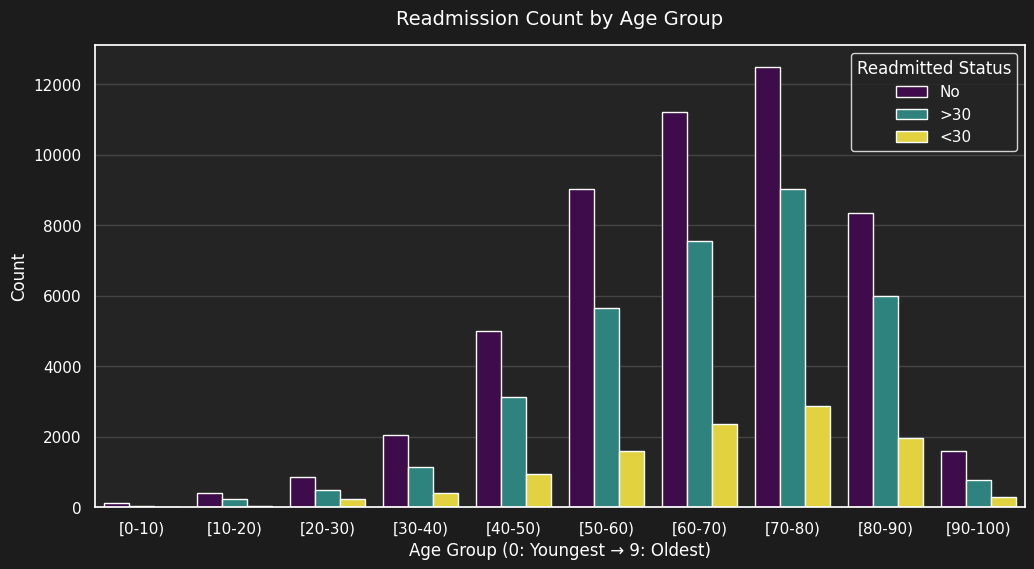

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_c, x='age', hue='readmitted', palette='viridis')
plt.title('Readmission Count by Age Group', color='white', fontsize=14, pad=15)
plt.xlabel('Age Group (0: Youngest → 9: Oldest)', color='white')
plt.ylabel('Count', color='white')
legend = plt.legend(title='Readmitted Status', labels=['No', '>30', '<30'],
                    facecolor='#242424', edgecolor='white')
plt.setp(legend.get_texts(), color='white')
plt.setp(legend.get_title(), color='white')
plt.show()

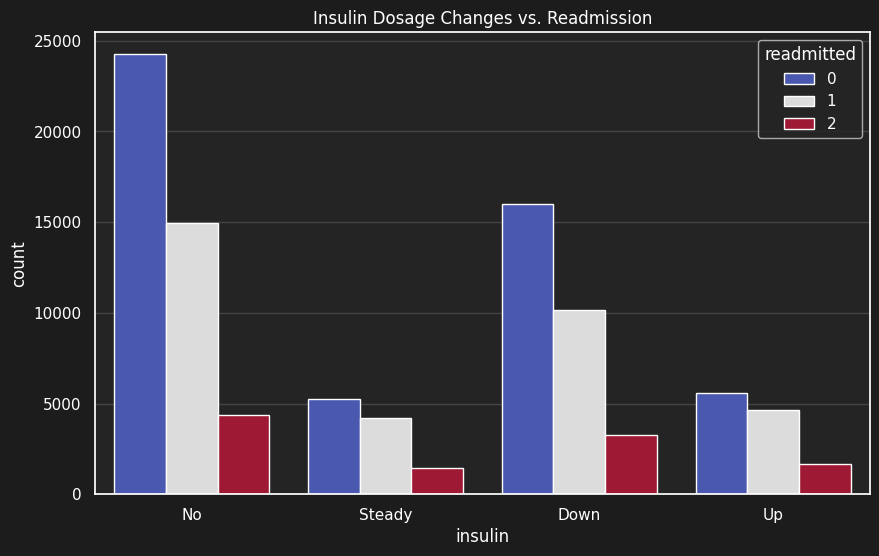

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_c, x='insulin', hue='readmitted', palette='coolwarm')
plt.title('Insulin Dosage Changes vs. Readmission')
plt.xticks([0, 1, 2, 3], ['No', 'Steady', 'Down', 'Up'])
plt.show()

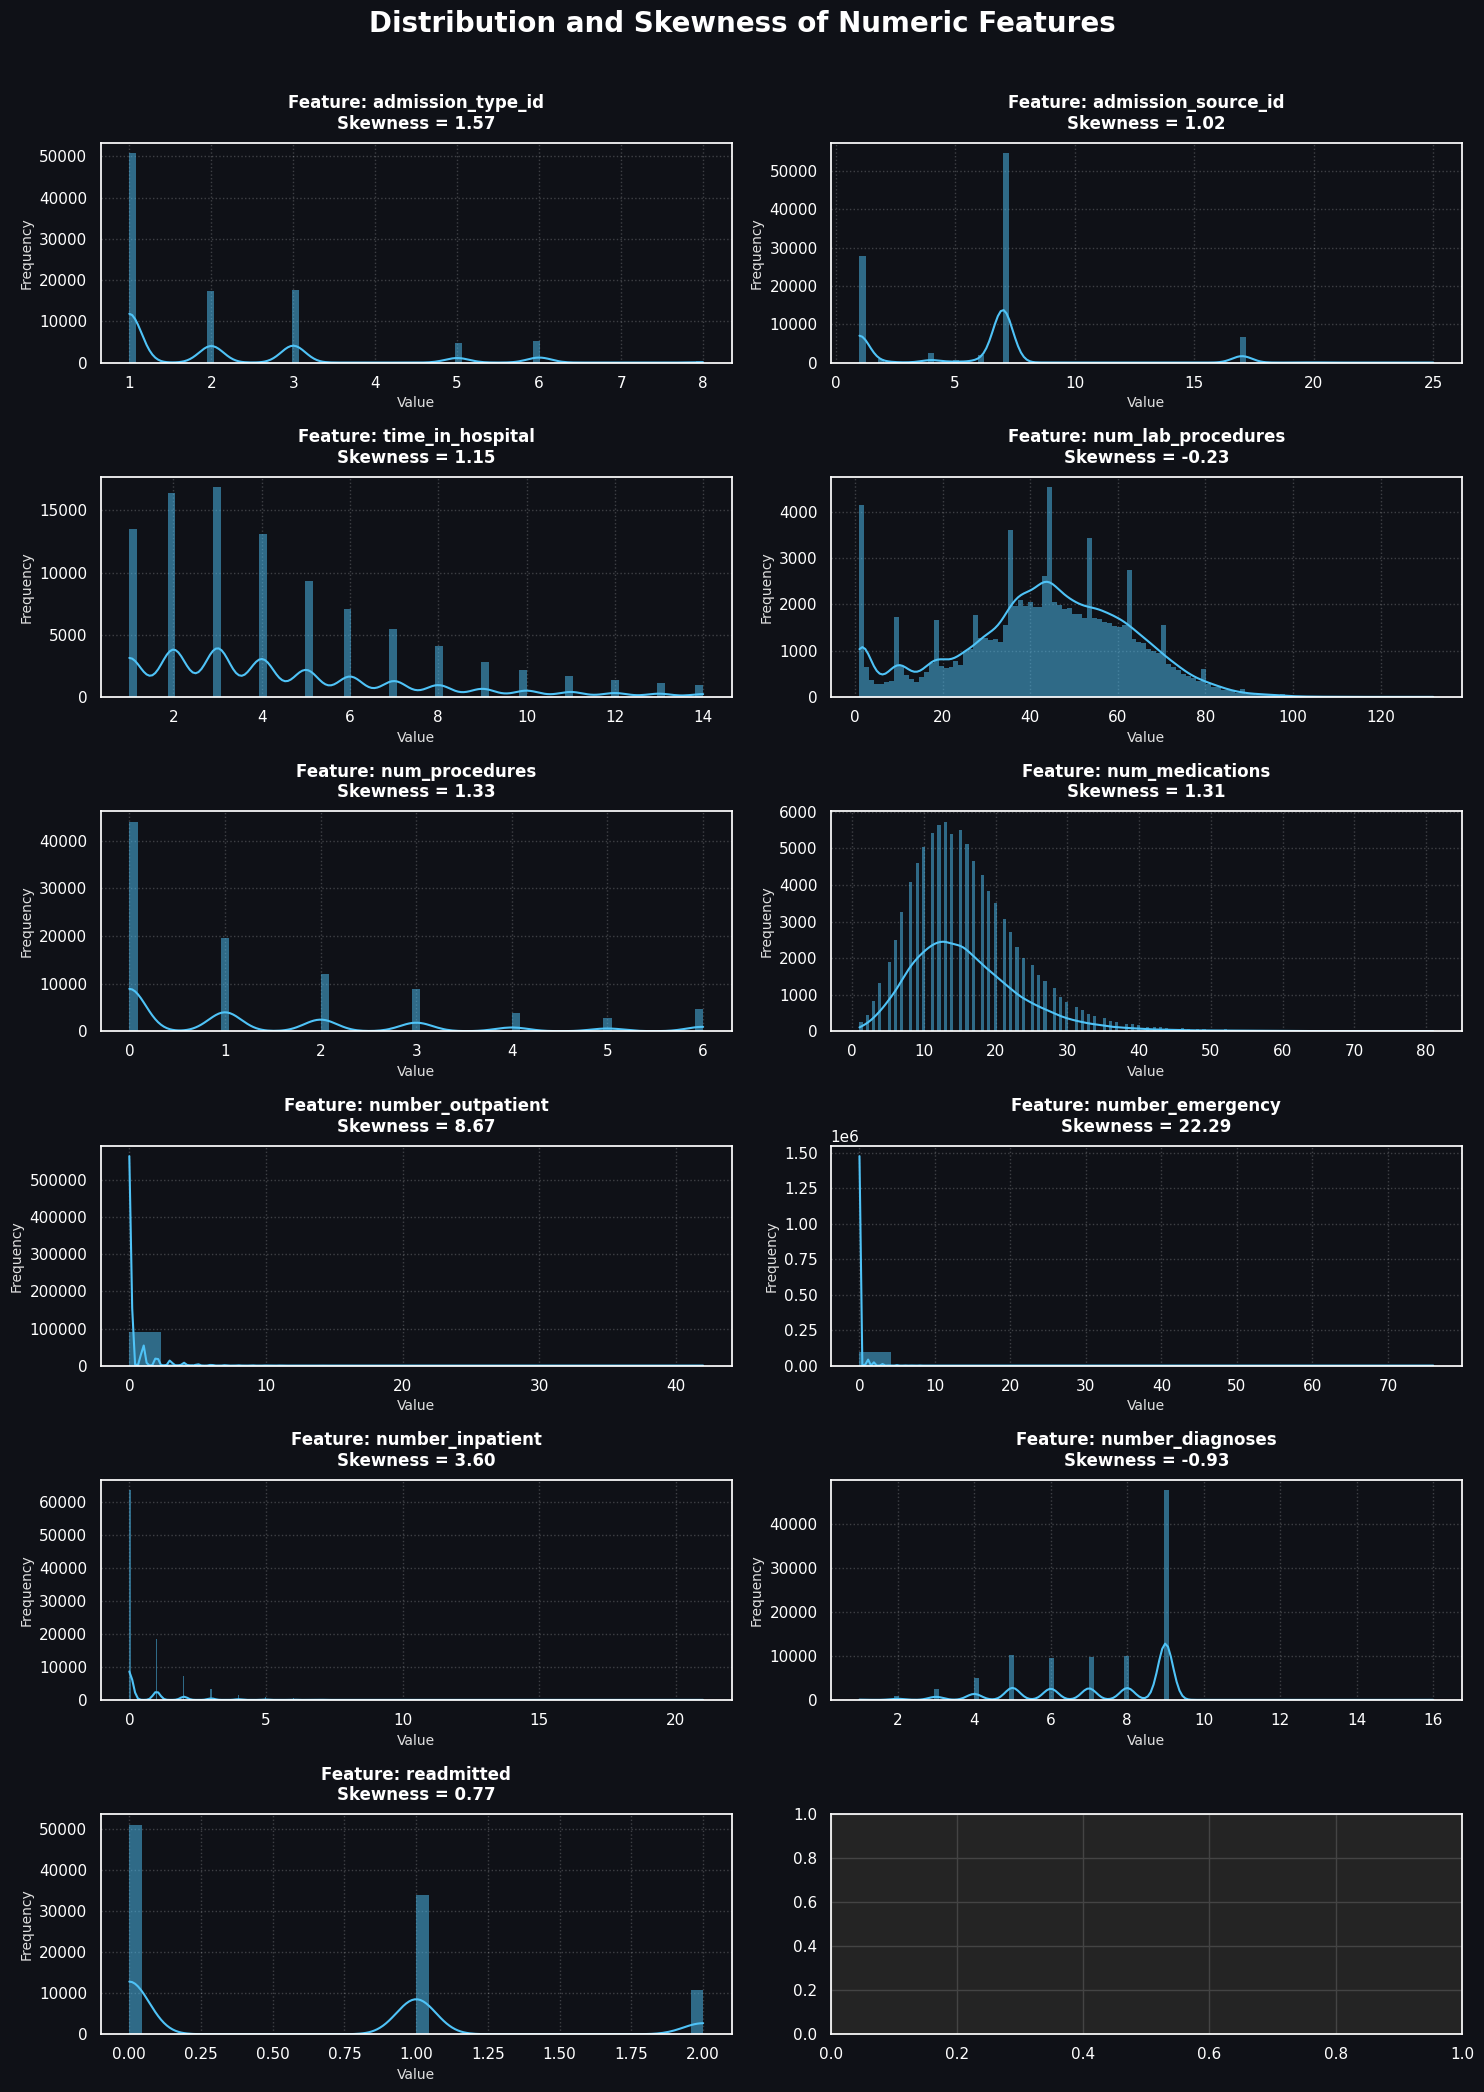

In [15]:
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 22))
fig.set_facecolor('#0f1117')
axes_flat = axes.flatten()

for i, col in enumerate(df_num):
    if i >= len(axes_flat):
        break
    ax = axes_flat[i]
    ax.set_facecolor('#0f1117')
    skew_val = df_c[col].skew()
    sns.histplot(df_c[col], kde=True, color='#4FC3F7', edgecolor='none', ax=ax)
    ax.set_title(f"Feature: {col}\nSkewness = {skew_val:.2f}",
                 fontsize=12, color='white', fontweight='bold', pad=10)
    ax.set_xlabel("Value", fontsize=10, color='#e0e0e0')
    ax.set_ylabel("Frequency", fontsize=10, color='#e0e0e0')
    ax.grid(True, linestyle=':', alpha=0.2, color='white')
    ax.tick_params(colors='white')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Distribution and Skewness of Numeric Features", color='white', fontsize=20, fontweight='bold')
plt.show()

In [16]:
cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient', 'num_medications', 'time_in_hospital']

for col in cols_to_fix:
    df_c[col] = np.log1p(df_c[col])

print("Skewness after Log Transformation:")
print(df_c[cols_to_fix].skew())

Skewness after Log Transformation:
number_emergency     3.546373
number_outpatient    2.668303
number_inpatient     1.433748
num_medications     -0.499344
time_in_hospital     0.111122
dtype: float64


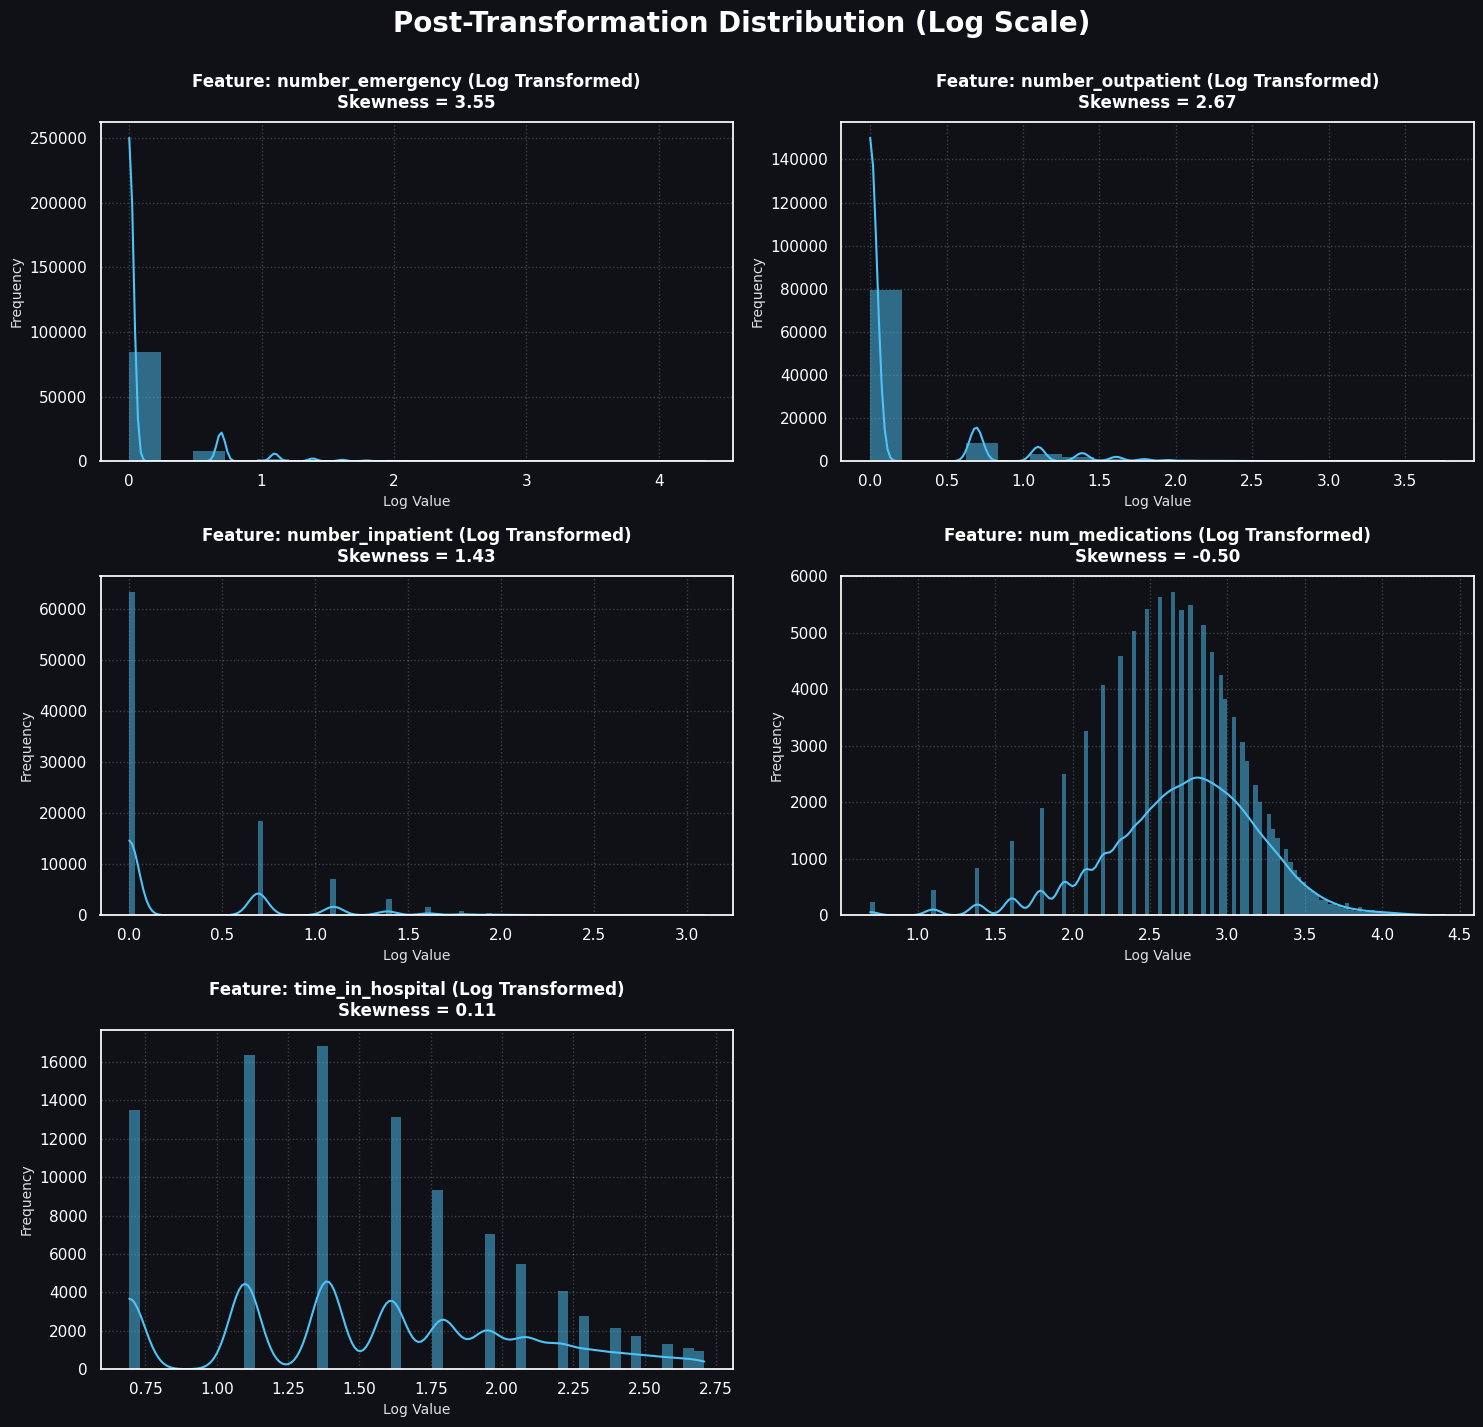

In [17]:
cols_to_fix = ['number_emergency', 'number_outpatient', 'number_inpatient', 'num_medications', 'time_in_hospital']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
fig.set_facecolor('#0f1117')
axes_flat = axes.flatten()

for i, col in enumerate(cols_to_fix):
    ax = axes_flat[i]
    ax.set_facecolor('#0f1117')
    skew_val = df_c[col].skew()
    sns.histplot(df_c[col], kde=True, color='#4FC3F7', edgecolor='none', ax=ax)
    ax.set_title(f"Feature: {col} (Log Transformed)\nSkewness = {skew_val:.2f}",
                 fontsize=12, color='white', fontweight='bold', pad=10)
    ax.set_xlabel("Log Value", fontsize=10, color='#e0e0e0')
    ax.set_ylabel("Frequency", fontsize=10, color='#e0e0e0')
    ax.grid(True, linestyle=':', alpha=0.2, color='white')
    ax.tick_params(colors='white')

axes_flat[5].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Post-Transformation Distribution (Log Scale)", color='white', fontsize=20, fontweight='bold')
plt.show()

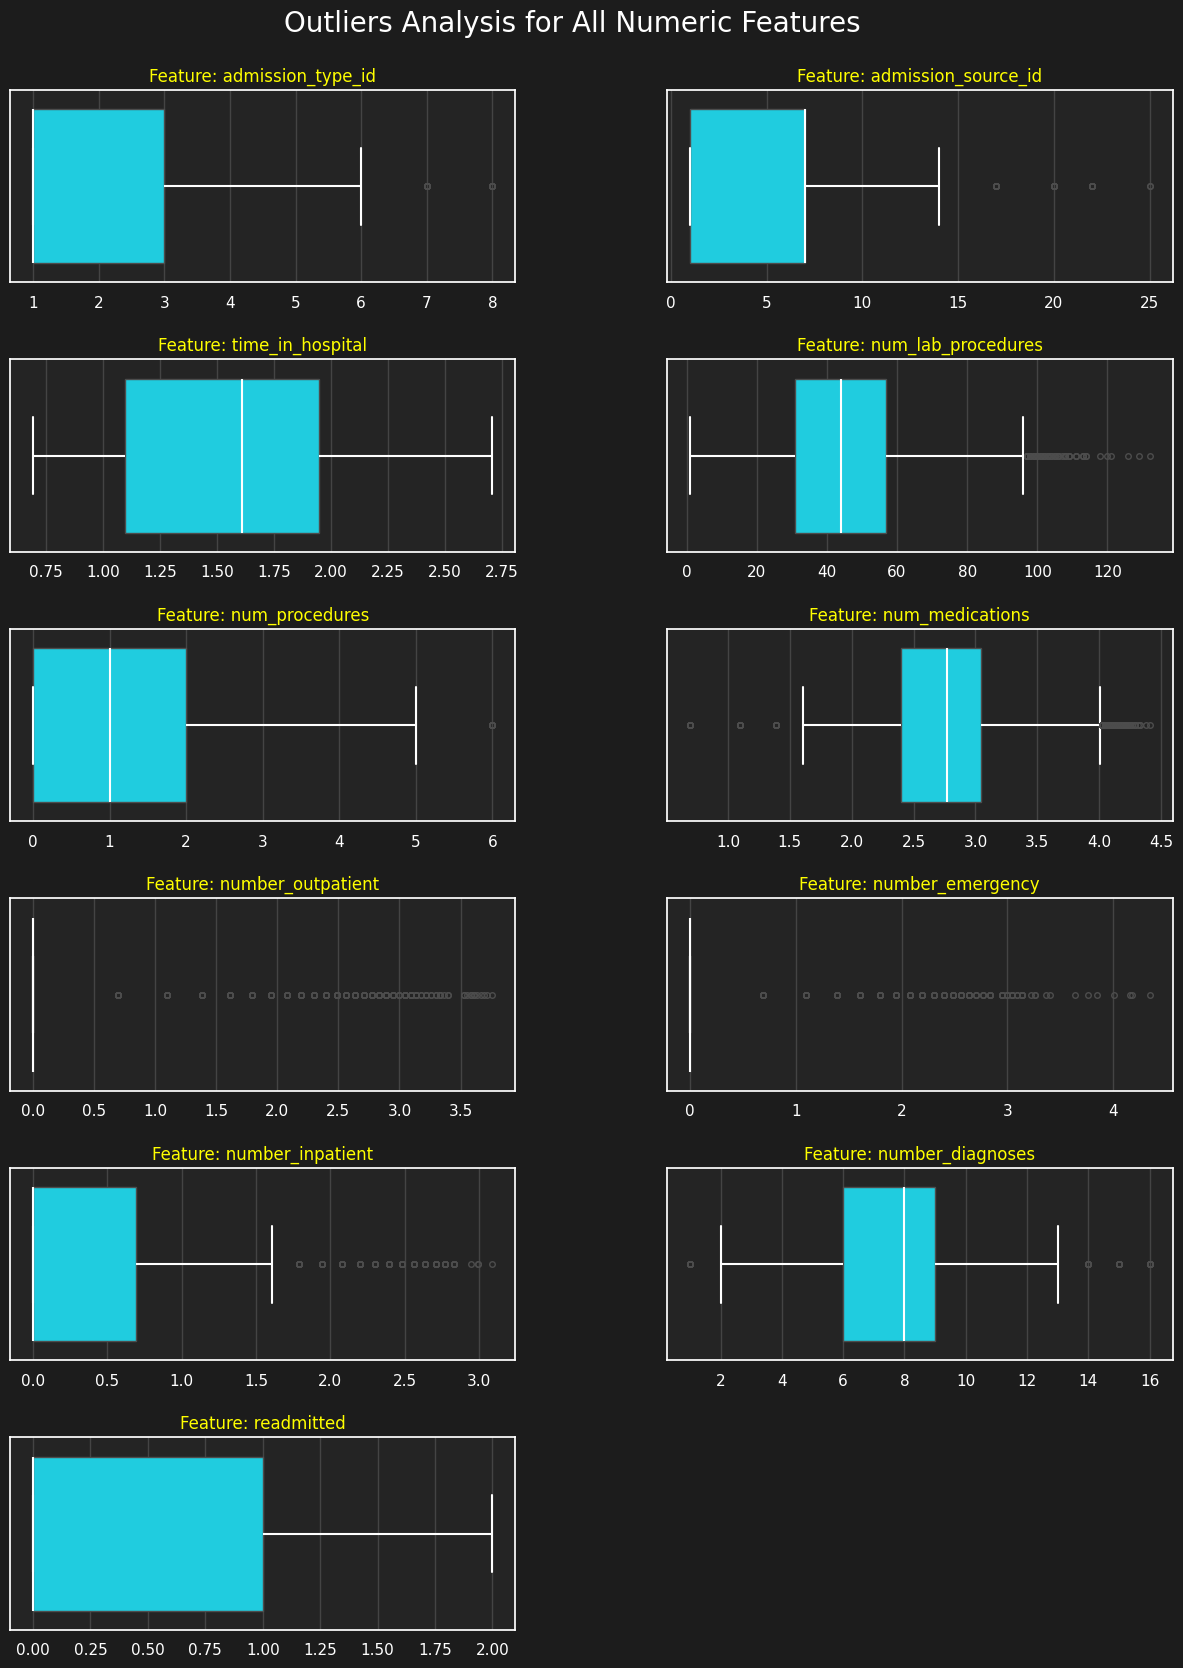

In [18]:
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#242424",
    "figure.facecolor": "#1c1c1c",
    "grid.color": "#444444",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(15, 20))
fig.subplots_adjust(hspace=0.4, wspace=0.3)
fig.suptitle('Outliers Analysis for All Numeric Features', color='white', fontsize=20, y=0.92)
axes_flat = axes.flatten()

for i, col in enumerate(df_num):
    ax = axes_flat[i]
    sns.boxplot(x=df_c[col], ax=ax, color='#00e5ff', fliersize=4)
    plt.setp(ax.artists, edgecolor="white", linewidth=1.5)
    plt.setp(ax.lines, color="white", linewidth=1.5)
    ax.set_title(f'Feature: {col}', color='yellow', fontsize=12)
    ax.set_xlabel('')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.show()

In [19]:
print(f"{'Feature':<25} | {'Outliers Count':<15} | {'Percentage':<10}")
print("-" * 55)
total_rows = len(df_c)

for col in df_num:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_c[(df_c[col] < lower_bound) | (df_c[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / total_rows) * 100
    print(f"{col:<25} | {count:<15} | {percentage:.2f}%")

Feature                   | Outliers Count  | Percentage
-------------------------------------------------------
admission_type_id         | 337             | 0.35%
admission_source_id       | 6866            | 7.17%
time_in_hospital          | 0               | 0.00%
num_lab_procedures        | 142             | 0.15%
num_procedures            | 4582            | 4.78%
num_medications           | 1770            | 1.85%
number_outpatient         | 16389           | 17.10%
number_emergency          | 11272           | 11.76%
number_inpatient          | 1960            | 2.05%
number_diagnoses          | 261             | 0.27%
readmitted                | 0               | 0.00%


In [20]:
safe_cols_to_clean = [ 'num_lab_procedures', 'num_medications', 'number_diagnoses', 'time_in_hospital']
print(f"Original shape: {df_c.shape}")

for col in safe_cols_to_clean:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_c = df_c[(df_c[col] >= lower_bound) & (df_c[col] <= upper_bound)]

print(f"Fixed shape: {df_c.shape}")

Original shape: (95818, 27)
Fixed shape: (93700, 27)


In [21]:
print(f"{'Feature':<25} | {'Outliers Count':<15} | {'Percentage':<10}")
print("-" * 55)
total_rows = len(df_c)

for col in df_num:
    Q1 = df_c[col].quantile(0.25)
    Q3 = df_c[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_c[(df_c[col] < lower_bound) | (df_c[col] > upper_bound)]
    count = len(outliers)
    percentage = (count / total_rows) * 100
    print(f"{col:<25} | {count:<15} | {percentage:.2f}%")

Feature                   | Outliers Count  | Percentage
-------------------------------------------------------
admission_type_id         | 328             | 0.35%
admission_source_id       | 6765            | 7.22%
time_in_hospital          | 0               | 0.00%
num_lab_procedures        | 0               | 0.00%
num_procedures            | 4386            | 4.68%
num_medications           | 1581            | 1.69%
number_outpatient         | 16160           | 17.25%
number_emergency          | 11102           | 11.85%
number_inpatient          | 1944            | 2.07%
number_diagnoses          | 0               | 0.00%
readmitted                | 0               | 0.00%


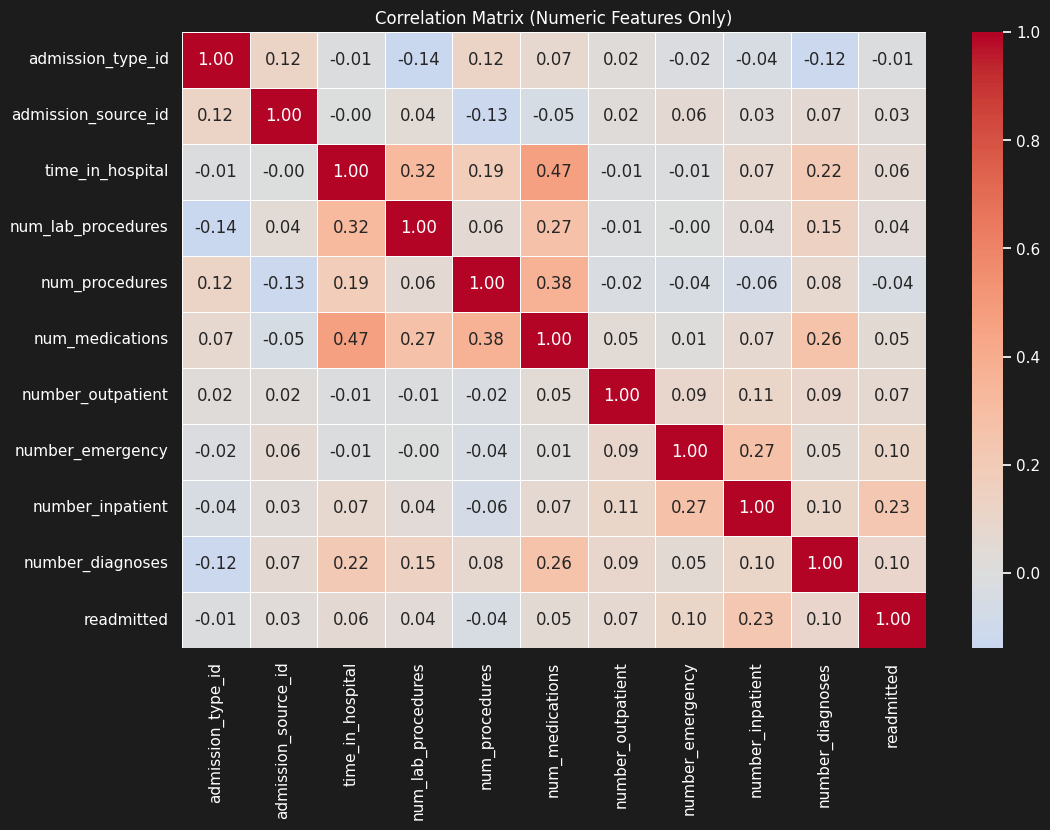

readmitted             1.000000
number_inpatient       0.233497
number_emergency       0.104288
number_diagnoses       0.100961
number_outpatient      0.067485
time_in_hospital       0.057634
num_medications        0.054058
num_lab_procedures     0.036428
admission_source_id    0.028534
admission_type_id     -0.008632
num_procedures        -0.036341
Name: readmitted, dtype: float64


In [22]:
corr_matrix = df_num.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True,
            fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

corr_with_target = corr_matrix['readmitted'].sort_values(ascending=False)
print(corr_with_target)
# need to drop  admission_type_id  &&  num_procedures

#**Feature Engineering/Selection**
----------------------------------------------------------------------------------------
--------------------------------------------------------------------


In [23]:
age_dummies = pd.get_dummies(
    df_c['age'],
    prefix='age',
    drop_first=False
)

age_dummies = age_dummies.astype(int)

df_c = df_c.drop(columns=['age'])
df_c = pd.concat([df_c, age_dummies], axis=1)


In [24]:
df_c = df_c.drop(columns=['admission_type_id', 'num_procedures'])

In [25]:
cat_cols = ['race', 'gender', 'change', 'diabetesMed',
            'discharge_group', 'diag_1', 'diag_2', 'diag_3']
df_c = pd.get_dummies(df_c, columns=cat_cols, drop_first=True)

In [26]:
df_c['admission_source_id'] = df_c['admission_source_id'].astype(str)
df_c = pd.get_dummies(df_c, columns=['admission_source_id'], drop_first=True)

In [27]:
drop_cols = [
    'admission_source_id_8',
    'admission_source_id_9',
    'admission_source_id_10',
    'admission_source_id_11',
    'admission_source_id_13',
    'admission_source_id_14',
    'admission_source_id_22',
    'admission_source_id_25',
    'diag_1_External_Causes',
    'diag_1_Other',
    'diag_1_Congenital',
    'diag_2_Congenital',
    'diag_3_Congenital',
]
df_c = df_c.drop(columns=drop_cols)

In [28]:
cats = df_c.select_dtypes(include='object').columns.tolist()
for col in cats:
    print(col, df_c[col].unique())

metformin ['No' 'Steady' 'Up' 'Down']
glimepiride ['No' 'Steady' 'Down' 'Up']
glipizide ['No' 'Steady' 'Up' 'Down']
glyburide ['No' 'Steady' 'Up' 'Down']
pioglitazone ['No' 'Steady' 'Up' 'Down']
rosiglitazone ['No' 'Steady' 'Up' 'Down']
insulin ['Up' 'No' 'Steady' 'Down']


In [29]:
med_map = {'No': 0, 'Steady': 1, 'Down': 2, 'Up': 3}
med_cols = ['metformin','glimepiride','glipizide',
            'glyburide','pioglitazone','rosiglitazone','insulin']
for col in med_cols:
    df_c[col] = df_c[col].map(med_map)

In [30]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93700 entries, 1 to 101764
Data columns (total 97 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   time_in_hospital           93700 non-null  float64
 1   num_lab_procedures         93700 non-null  int64  
 2   num_medications            93700 non-null  float64
 3   number_outpatient          93700 non-null  float64
 4   number_emergency           93700 non-null  float64
 5   number_inpatient           93700 non-null  float64
 6   number_diagnoses           93700 non-null  int64  
 7   metformin                  93700 non-null  int64  
 8   glimepiride                93700 non-null  int64  
 9   glipizide                  93700 non-null  int64  
 10  glyburide                  93700 non-null  int64  
 11  pioglitazone               93700 non-null  int64  
 12  rosiglitazone              93700 non-null  int64  
 13  insulin                    93700 non-null  int64  

In [31]:
for col in df_c.columns:
    print("="*50)
    print(f"Column: {col}")
    print("-"*50)
    print(df_c[col].value_counts(dropna=False))
    print("\n")

Column: time_in_hospital
--------------------------------------------------
time_in_hospital
1.386294    16583
1.098612    15889
1.609438    13005
0.693147    12735
1.791759     9269
1.945910     6974
2.079442     5400
2.197225     4010
2.302585     2739
2.397895     2123
2.484907     1673
2.564949     1304
2.639057     1069
2.708050      927
Name: count, dtype: int64


Column: num_lab_procedures
--------------------------------------------------
num_lab_procedures
1     2958
43    2560
44    2280
45    2179
38    2038
      ... 
93      54
94      45
95      44
92      41
96      28
Name: count, Length: 96, dtype: int64


Column: num_medications
--------------------------------------------------
num_medications
2.639057    5721
2.564949    5630
2.772589    5492
2.484907    5422
2.708050    5393
2.833213    5126
2.397895    5022
2.890372    4659
2.302585    4585
2.944439    4252
2.197225    4057
2.995732    3819
3.044522    3495
2.079442    3240
3.091042    3056
3.135494    2718
1.9459

paper refrence:
https://drive.google.com/file/d/1SfTv7nT4pWlYSdQO4RWU0Pu1P_-3mEDY/view?usp=sharing


# **Training — Logistic Regression (Multiclass)**

---

Target classes:
- **0** → No Readmission
- **1** → Readmitted after >30 days
- **2** → Readmitted within <30 days (critical)

---

In [32]:
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics         import (accuracy_score, f1_score, roc_auc_score,
                                      roc_curve, auc as auc_score,
                                      confusion_matrix, classification_report,
                                      ConfusionMatrixDisplay)
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


## Step 1 — Prepare Data

In [33]:
TARGET = 'readmitted'


X = df_c.drop(columns=[TARGET])
y = df_c[TARGET]

X = X.select_dtypes(include=[np.number])

print(f'Feature matrix shape : {X.shape}')
print(f'Class distribution   :')
print(y.value_counts().rename({0: 'No Readmit (0)',
                                 1: '>30 Days (1)',
                                 2: '<30 Days (2)'}))

Feature matrix shape : (93700, 24)
Class distribution   :
readmitted
No Readmit (0)    49674
>30 Days (1)      33484
<30 Days (2)      10542
Name: count, dtype: int64


## Step 2 — Train / Test Split (80 / 20)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train size : {X_train.shape[0]:,} rows')
print(f'Test  size : {X_test.shape[0]:,} rows')

Train size : 74,960 rows
Test  size : 18,740 rows


## Step 3 — Build Pipeline

SMOTE → StandardScaler → LogisticRegression inside `ImbPipeline`
so SMOTE is applied **only on training folds** (no data leakage).

In [35]:
lr_pipeline = ImbPipeline(steps=[
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
                   max_iter     = 1000,
                   solver       = 'lbfgs',
                   C            = 1.0,
                   class_weight = 'balanced',
                   random_state = 42
               ))
])

print('Pipeline defined ✓')
print(lr_pipeline)

Pipeline defined ✓
Pipeline(steps=[('smote', SMOTE(random_state=42)), ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])


## Step 4 — 10-Fold Cross-Validation

In [36]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_acc = cross_val_score(lr_pipeline, X_train, y_train, cv=cv,
                          scoring='accuracy',             n_jobs=-1)
cv_f1  = cross_val_score(lr_pipeline, X_train, y_train, cv=cv,
                          scoring='f1_weighted',          n_jobs=-1)
cv_auc = cross_val_score(lr_pipeline, X_train, y_train, cv=cv,
                          scoring='roc_auc_ovr_weighted', n_jobs=-1)

def ci95(scores):
    """Return mean ± 1.96*std (95% CI) string."""
    return f'{scores.mean()*100:.2f}% ± {1.96*scores.std()*100:.2f}%'

print('── 10-Fold Cross-Validation Results (Logistic Regression) ──')
print(f'  Accuracy  (95% CI): {ci95(cv_acc)}')
print(f'  F1-Score  (95% CI): {ci95(cv_f1)}')
print(f'  AUC-ROC   (95% CI): {ci95(cv_auc)}')

── 10-Fold Cross-Validation Results (Logistic Regression) ──
  Accuracy  (95% CI): 49.62% ± 1.33%
  F1-Score  (95% CI): 49.15% ± 1.23%
  AUC-ROC   (95% CI): 61.12% ± 1.53%


## Step 5 — Fit & Evaluate on Hold-out Test Set

In [50]:
lr_pipeline.fit(X_train, y_train)

y_pred      = lr_pipeline.predict(X_test)
y_pred_prob = lr_pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred) * 100
f1  = f1_score(y_test, y_pred, average='weighted') * 100
model_auc_score = roc_auc_score(y_test, y_pred_prob,
                    multi_class='ovr',
                    average='weighted') * 100

print('── Hold-out Test Set Performance (Logistic Regression) ──')
print(f'  Accuracy : {acc:.2f}%')
print(f'  F1-Score : {f1:.2f}%')
print(f'  AUC-ROC  : {model_auc_score:.2f}%')
print(f'  Average  : {(acc+f1+model_auc_score)/3:.2f}%')
print()
print(classification_report(y_test, y_pred,
                              target_names=['No Readmit (0)', '>30 Days (1)', '<30 Days (2)']))

── Hold-out Test Set Performance (Logistic Regression) ──
  Accuracy : 50.17%
  F1-Score : 49.85%
  AUC-ROC  : 61.79%
  Average  : 53.94%

                precision    recall  f1-score   support

No Readmit (0)       0.62      0.69      0.65      9935
  >30 Days (1)       0.48      0.29      0.36      6697
  <30 Days (2)       0.17      0.29      0.21      2108

      accuracy                           0.50     18740
     macro avg       0.42      0.42      0.41     18740
  weighted avg       0.52      0.50      0.50     18740



## Step 6 — Performance Visualisation

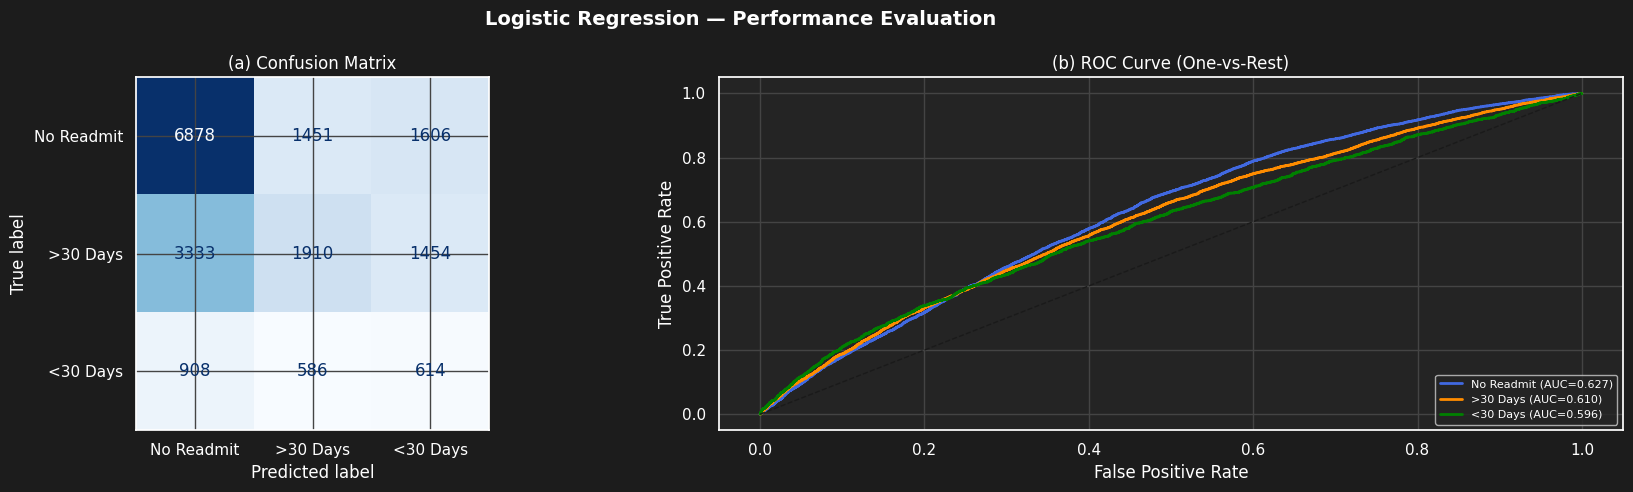

Figure saved → lr_performance.png


In [38]:
from sklearn.metrics import auc

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Logistic Regression — Performance Evaluation',
             fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Readmit', '>30 Days', '<30 Days']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('(a) Confusion Matrix')

classes     = [0, 1, 2]
class_names = ['No Readmit', '>30 Days', '<30 Days']
colors      = ['royalblue', 'darkorange', 'green']
y_test_bin  = label_binarize(y_test, classes=classes)

for i, (cls_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'{cls_name} (AUC={auc(fpr, tpr):.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('(b) ROC Curve (One-vs-Rest)')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('lr_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → lr_performance.png')


In [39]:
lr_model = lr_pipeline.named_steps['model']

X_test_scaled    = lr_pipeline.named_steps['scaler'].transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

masker      = shap.maskers.Independent(X_test_scaled_df)
explainer   = shap.LinearExplainer(lr_model, masker)
shap_values = explainer.shap_values(X_test_scaled_df)

print(f'SHAP values computed ✓  —  shape per class: {shap_values[0].shape}')


SHAP values computed ✓  —  shape per class: (24, 3)


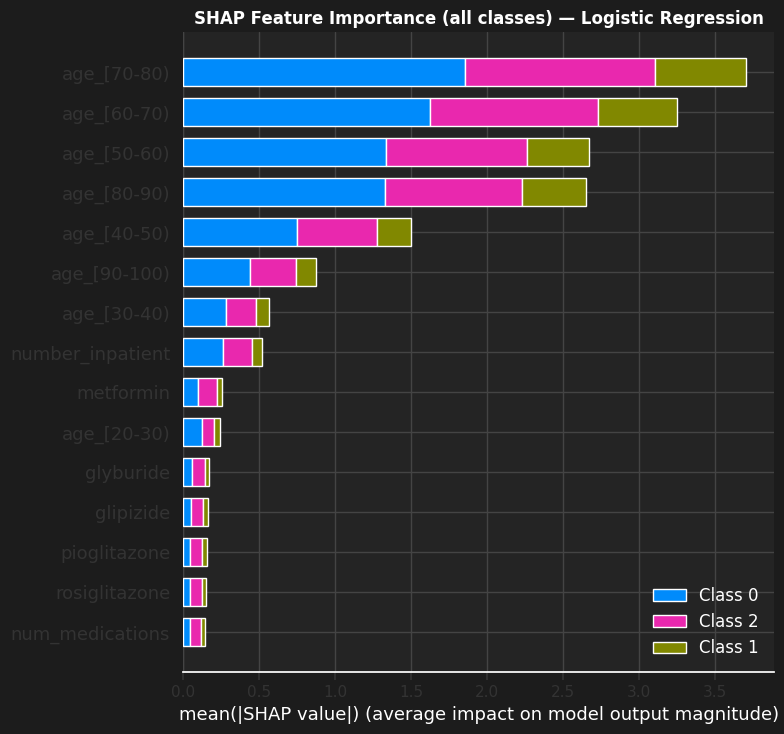

Figure saved → lr_shap_bar_allclasses.png


In [40]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_scaled_df,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('SHAP Feature Importance (all classes) — Logistic Regression',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_shap_bar_allclasses.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → lr_shap_bar_allclasses.png')



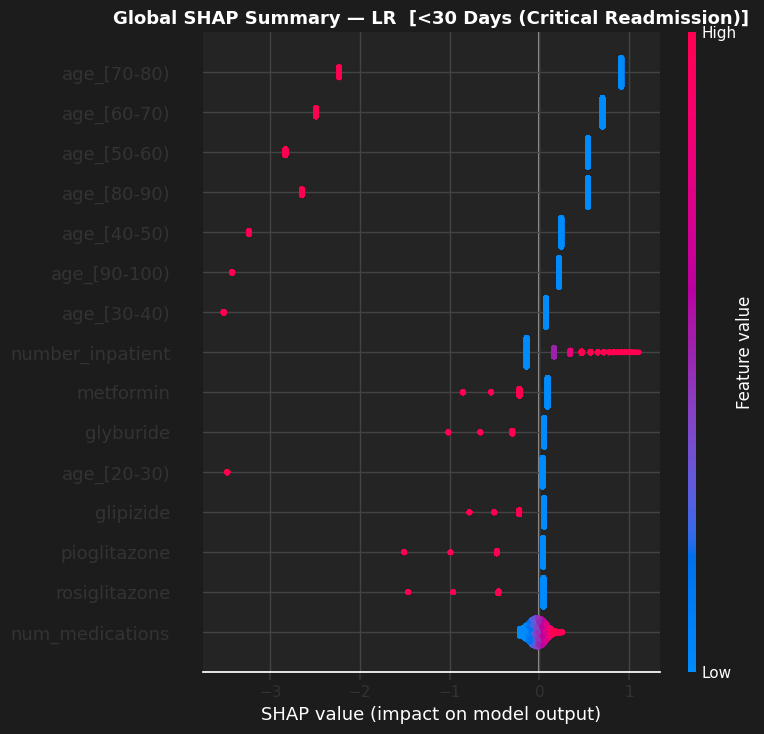

Figure saved → lr_shap_summary_class2.png


In [41]:
TARGET_CLASS      = 2
TARGET_CLASS_NAME = '<30 Days (Critical Readmission)'

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values[:, :, TARGET_CLASS],
    X_test_scaled_df,
    max_display=15,
    show=False
)
plt.title(f'Global SHAP Summary — LR  [{TARGET_CLASS_NAME}]',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_shap_summary_class2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → lr_shap_summary_class2.png')


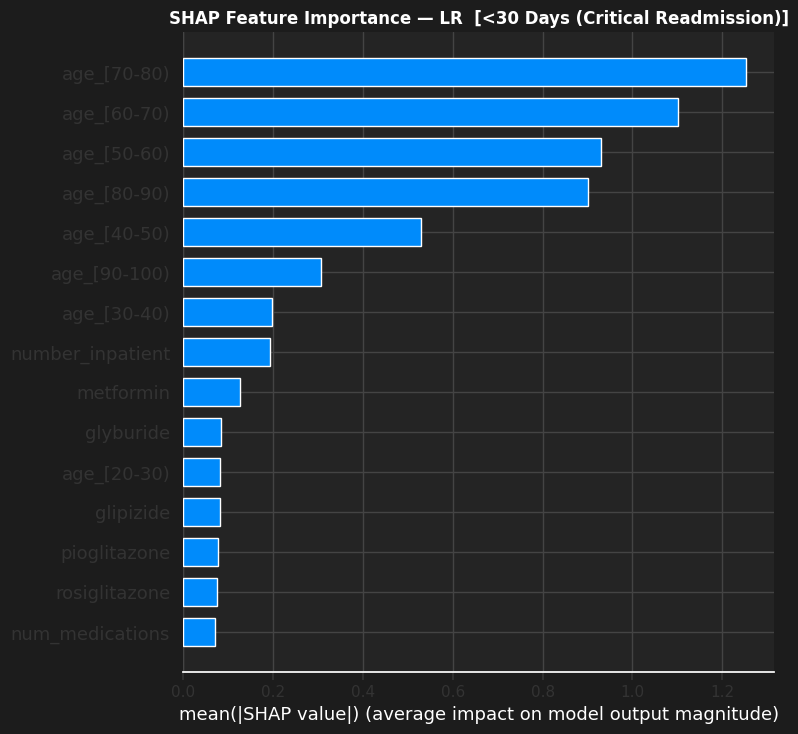

Figure saved → lr_shap_bar_class2.png


In [42]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, TARGET_CLASS],
    X_test_scaled_df,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title(f'SHAP Feature Importance — LR  [{TARGET_CLASS_NAME}]',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_shap_bar_class2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → lr_shap_bar_class2.png')


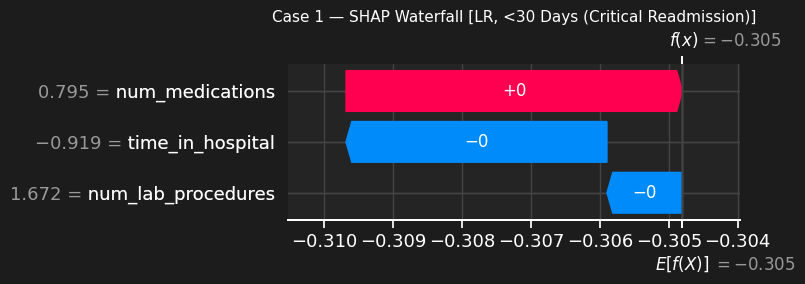

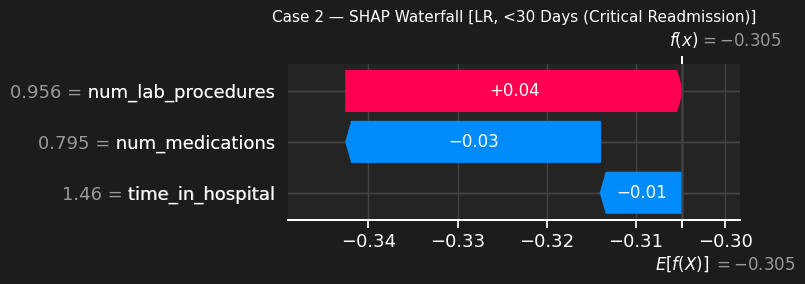

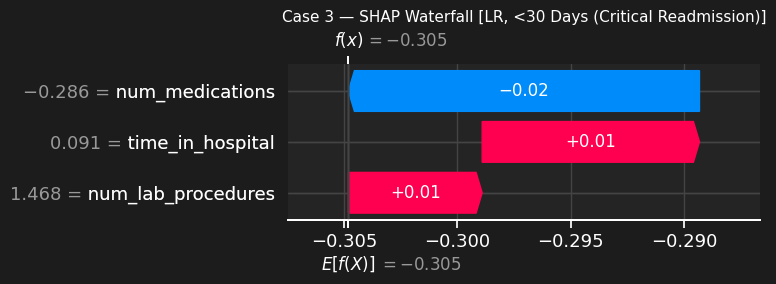

Case-specific waterfall plots saved ✓


In [43]:
for case_idx, label in [(0, 'Case 1'), (1, 'Case 2'), (2, 'Case 3')]:
    plt.figure(figsize=(12, 4))
    shap_exp = shap.Explanation(
        values        = shap_values[TARGET_CLASS][case_idx],
        base_values   = explainer.expected_value[TARGET_CLASS],
        data          = X_test_scaled_df.iloc[case_idx].values,
        feature_names = X.columns.tolist()
    )
    shap.plots.waterfall(shap_exp, max_display=10, show=False)
    plt.title(f'{label} — SHAP Waterfall [LR, {TARGET_CLASS_NAME}]', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'lr_shap_{label.replace(" ","_").lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

print('Case-specific waterfall plots saved ✓')


## Step 8 — Feature Importance via Coefficients

After scaling, `mean |coefficient|` across all 3 classes shows overall feature influence.

📊 FEATURE IMPORTANCE — LR COEFFICIENTS (After Training)
           Feature  Mean_AbsCoef  Coef_Class2 Decision
       age_[70-80)      1.342455    -1.362131     KEEP
       age_[60-70)      1.278136    -1.299896     KEEP
       age_[80-90)      1.160600    -1.182200     KEEP
       age_[50-60)      1.152549    -1.204420     KEEP
       age_[40-50)      0.883615    -0.935720     KEEP
       age_[30-40)      0.555018    -0.585667     KEEP
      age_[90-100)      0.495454    -0.520525     KEEP
       age_[20-30)      0.371588    -0.379615     KEEP
  number_inpatient      0.212830     0.238539     KEEP
       age_[10-20)      0.210319    -0.253052     KEEP
        age_[0-10)      0.097474    -0.123030     KEEP
         metformin      0.093276    -0.139915     KEEP
      pioglitazone      0.088562    -0.132843     KEEP
         glyburide      0.085449    -0.128174     KEEP
       glimepiride      0.078971    -0.118457     KEEP
     rosiglitazone      0.077817    -0.116725     KEEP
         

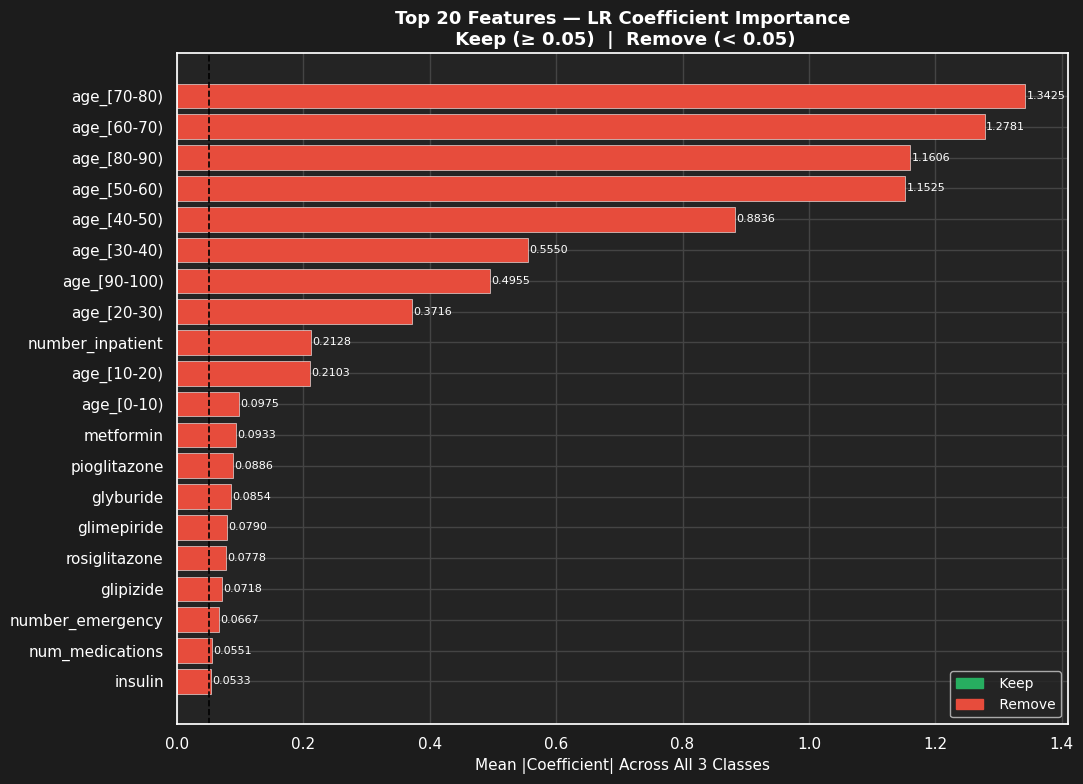

Figure saved → lr_coef_top20.png


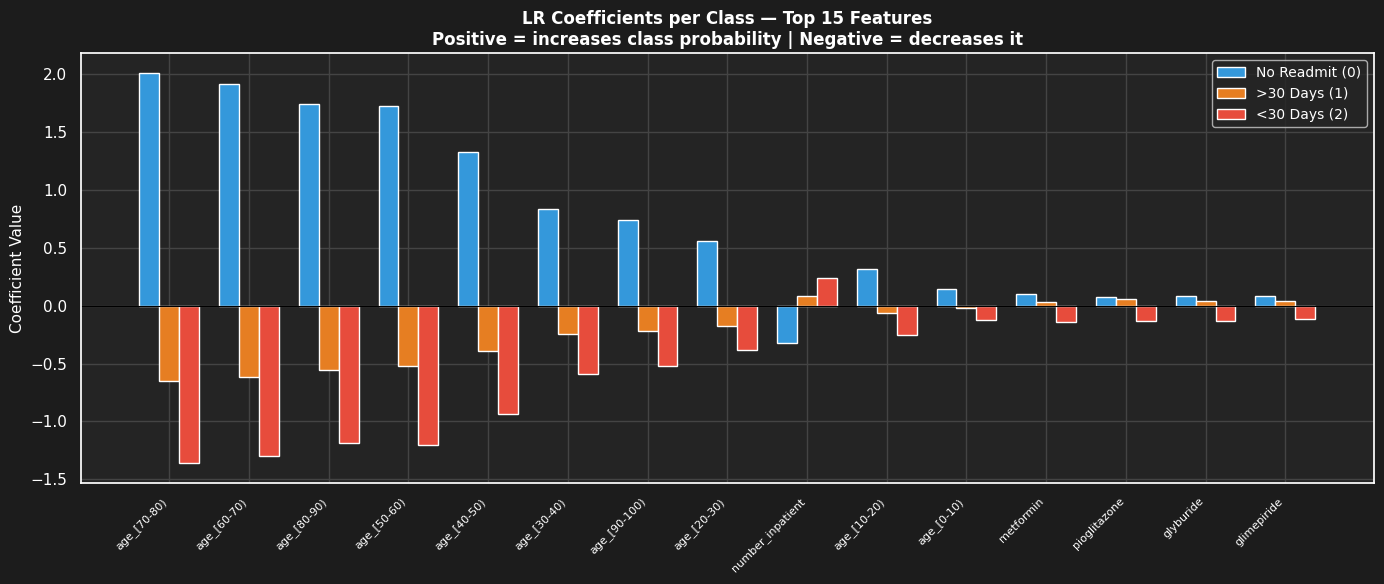

Figure saved → lr_coef_per_class.png


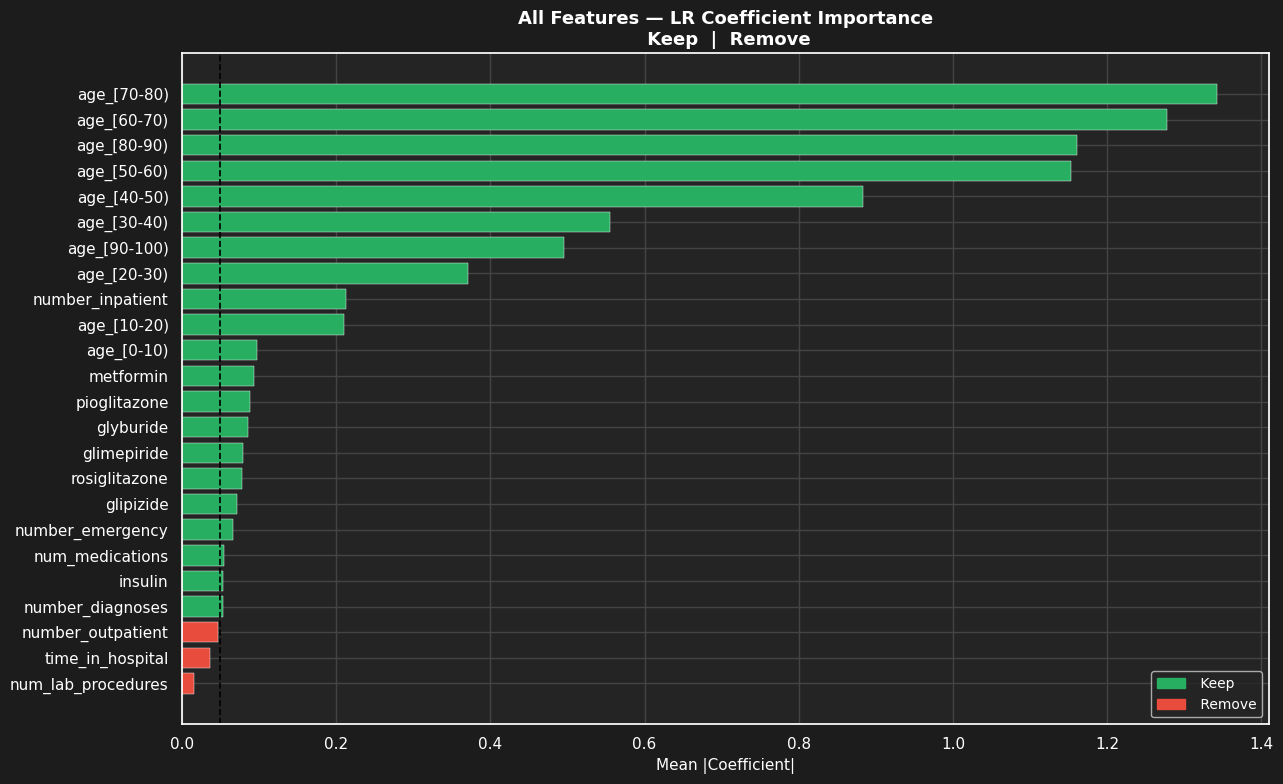

Figure saved → lr_coef_all_features.png


In [44]:

lr_model = lr_pipeline.named_steps['model']

coef_matrix = pd.DataFrame(
    lr_model.coef_,
    index  = ['No Readmit (0)', '>30 Days (1)', '<30 Days (2)'],
    columns= X.columns
)

mean_abs_coef = np.abs(coef_matrix).mean(axis=0)

coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Mean_AbsCoef': mean_abs_coef,
    'Coef_Class0' : coef_matrix.loc['No Readmit (0)'].values,
    'Coef_Class1' : coef_matrix.loc['>30 Days (1)'].values,
    'Coef_Class2' : coef_matrix.loc['<30 Days (2)'].values,
}).sort_values('Mean_AbsCoef', ascending=False).reset_index(drop=True)

THRESHOLD = 0.05
coef_df['Decision'] = coef_df['Mean_AbsCoef'].apply(
    lambda v: ' KEEP' if v >= THRESHOLD else ' REMOVE'
)

print('=' * 70)
print('📊 FEATURE IMPORTANCE — LR COEFFICIENTS (After Training)')
print('=' * 70)
print(coef_df[['Feature','Mean_AbsCoef','Coef_Class2','Decision']].to_string(index=False))
print(f"\n KEEP   : {(coef_df['Decision']==' KEEP').sum()} features")
print(f" REMOVE : {(coef_df['Decision']==' REMOVE').sum()} features")

import matplotlib.patches as mpatches

top20 = coef_df.head(20)
colors = ['#27ae60' if d == ' KEEP' else '#e74c3c'
          for d in top20['Decision']]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(
    top20['Feature'][::-1],
    top20['Mean_AbsCoef'][::-1],
    color=colors[::-1],
    edgecolor='white', linewidth=0.4
)

for bar, val in zip(bars, top20['Mean_AbsCoef'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=8)

ax.axvline(THRESHOLD, color='black', linestyle='--',
           linewidth=1.2, label=f'Threshold = {THRESHOLD}')

keep_p   = mpatches.Patch(color='#27ae60', label=' Keep')
remove_p = mpatches.Patch(color='#e74c3c', label=' Remove')
ax.legend(handles=[keep_p, remove_p], fontsize=10)

ax.set_xlabel('Mean |Coefficient| Across All 3 Classes', fontsize=11)
ax.set_title('Top 20 Features — LR Coefficient Importance\n'
             ' Keep (≥ 0.05)  |  Remove (< 0.05)',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('lr_coef_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → lr_coef_top20.png')


top15 = coef_df.head(15)

x    = np.arange(len(top15))
w    = 0.25
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x - w,   top15['Coef_Class0'], w, label='No Readmit (0)', color='#3498db')
ax.bar(x,       top15['Coef_Class1'], w, label='>30 Days (1)',   color='#e67e22')
ax.bar(x + w,   top15['Coef_Class2'], w, label='<30 Days (2)',   color='#e74c3c')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(top15['Feature'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('LR Coefficients per Class — Top 15 Features\n'
             'Positive = increases class probability | Negative = decreases it',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('lr_coef_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → lr_coef_per_class.png')


all_colors = ['#27ae60' if d == ' KEEP' else '#e74c3c'
              for d in coef_df['Decision']]

fig, ax = plt.subplots(figsize=(13, max(8, len(coef_df)*0.22)))
ax.barh(
    coef_df['Feature'][::-1],
    coef_df['Mean_AbsCoef'][::-1],
    color=all_colors[::-1],
    edgecolor='white', linewidth=0.3
)
ax.axvline(THRESHOLD, color='black', linestyle='--',
           linewidth=1.2, label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Mean |Coefficient|', fontsize=11)
ax.set_title('All Features — LR Coefficient Importance\n'
             ' Keep  |  Remove',
             fontsize=13, fontweight='bold')
ax.legend(handles=[keep_p, remove_p], fontsize=10)

plt.tight_layout()
plt.savefig('lr_coef_all_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → lr_coef_all_features.png')

In [45]:
FEATURES_TO_DROP = [
    'number_outpatient',
    'time_in_hospital',
    'num_lab_procedures'
]

print(' Dropping features:')
for f in FEATURES_TO_DROP:
    row = coef_df[coef_df['Feature'] == f].iloc[0]
    print(f'   {f:<25} |Coef| = {row["Mean_AbsCoef"]:.4f}')

X_reduced = X.drop(columns=FEATURES_TO_DROP)
print(f'\n Original features : {X.shape[1]}')
print(f' Reduced features  : {X_reduced.shape[1]}')
print(f' Dropped           : {len(FEATURES_TO_DROP)}')

 Dropping features:
   number_outpatient         |Coef| = 0.0471
   time_in_hospital          |Coef| = 0.0362
   num_lab_procedures        |Coef| = 0.0163

 Original features : 24
 Reduced features  : 21
 Dropped           : 3


In [46]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [47]:
lr_pipeline_r = ImbPipeline(steps=[
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
                   max_iter=1000, solver='lbfgs',
                   C=1.0, class_weight='balanced',
                   random_state=42
               ))
])

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_auc_r = cross_val_score(lr_pipeline_r, X_train_r, y_train_r,
                            cv=cv, scoring='roc_auc_ovr_weighted',
                            n_jobs=-1)
cv_f1_r  = cross_val_score(lr_pipeline_r, X_train_r, y_train_r,
                            cv=cv, scoring='f1_weighted',
                            n_jobs=-1)

In [51]:
lr_pipeline_r.fit(X_train_r, y_train_r)

y_pred_r      = lr_pipeline_r.predict(X_test_r)
y_pred_prob_r = lr_pipeline_r.predict_proba(X_test_r)

acc_r = accuracy_score(y_test_r, y_pred_r) * 100
f1_r  = f1_score(y_test_r, y_pred_r, average='weighted') * 100
auc_r = roc_auc_score(y_test_r, y_pred_prob_r,
                      multi_class='ovr', average='weighted') * 100

compare_df = pd.DataFrame({
    'Metric'      : ['Accuracy (%)', 'F1-Score (%)',
                     'AUC-ROC (%)', 'CV AUC (mean)',
                     '# Features'],
    'Full Model'  : [round(acc,2), round(f1,2),
                     round(model_auc_score,2),
                     round(cv_auc.mean()*100,2),
                     X.shape[1]],
    'Reduced Model': [round(acc_r,2), round(f1_r,2),
                      round(auc_r,2),
                      round(cv_auc_r.mean()*100,2),
                      X_reduced.shape[1]]
})

compare_df[' Change'] = compare_df.apply(
    lambda row: (
        f'+{float(str(row["Reduced Model"]).replace("%","")) - float(str(row["Full Model"]).replace("%","")):.2f}'
        if row['Metric'] != '# Features'
        else f'-{int(X.shape[1]) - int(X_reduced.shape[1])}'
    ), axis=1
)

print('\n' + '='*58)
print(' FULL vs REDUCED MODEL — PERFORMANCE COMPARISON')
print(f'   Dropped: {FEATURES_TO_DROP}')
print('='*58)
print(compare_df.to_string(index=False))


 FULL vs REDUCED MODEL — PERFORMANCE COMPARISON
   Dropped: ['number_outpatient', 'time_in_hospital', 'num_lab_procedures']
       Metric  Full Model  Reduced Model  Change
 Accuracy (%)       50.17          46.81  +-3.36
 F1-Score (%)       49.85          45.40  +-4.45
  AUC-ROC (%)       61.79          62.36   +0.57
CV AUC (mean)       61.12          61.67   +0.55
   # Features       24.00          21.00      -3


In [52]:
delta_auc = auc_r - model_auc_score
delta_f1  = f1_r  - f1
delta_acc = acc_r - acc

print('\n Interpretation:')
if delta_auc >= 0:
    print(f'   AUC improved by  {delta_auc:+.2f}% → safe to drop these features')
elif delta_auc >= -0.5:
    print(f' AUC dropped by  {delta_auc:.2f}% → very minor, still acceptable')
else:
    print(f' AUC dropped by  {delta_auc:.2f}% → consider keeping some features')


 Interpretation:
   AUC improved by  +0.58% → safe to drop these features


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Full Model vs Reduced Model (3 features dropped)\n'
             f'Dropped: {", ".join(FEATURES_TO_DROP)}',
             fontsize=12, fontweight='bold')

# (a) Bar chart comparison
metrics  = ['Accuracy (%)', 'F1-Score (%)', 'AUC-ROC (%)']
full_vals = [acc, f1, model_auc_score]
red_vals  = [acc_r, f1_r, auc_r]

x = np.arange(len(metrics))
w = 0.35
axes[0].bar(x - w/2, full_vals, w, label=f'Full ({X.shape[1]} features)',
            color='#3498db', alpha=0.85)
axes[0].bar(x + w/2, red_vals,  w, label=f'Reduced ({X_reduced.shape[1]} features)',
            color='#27ae60', alpha=0.85)

for i, (fv, rv) in enumerate(zip(full_vals, red_vals)):
    axes[0].text(i - w/2, fv + 0.1, f'{fv:.1f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, rv + 0.1, f'{rv:.1f}', ha='center', fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score (%)')
axes[0].set_title('(a) Metric Comparison')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 110)


(0.0, 110.0)

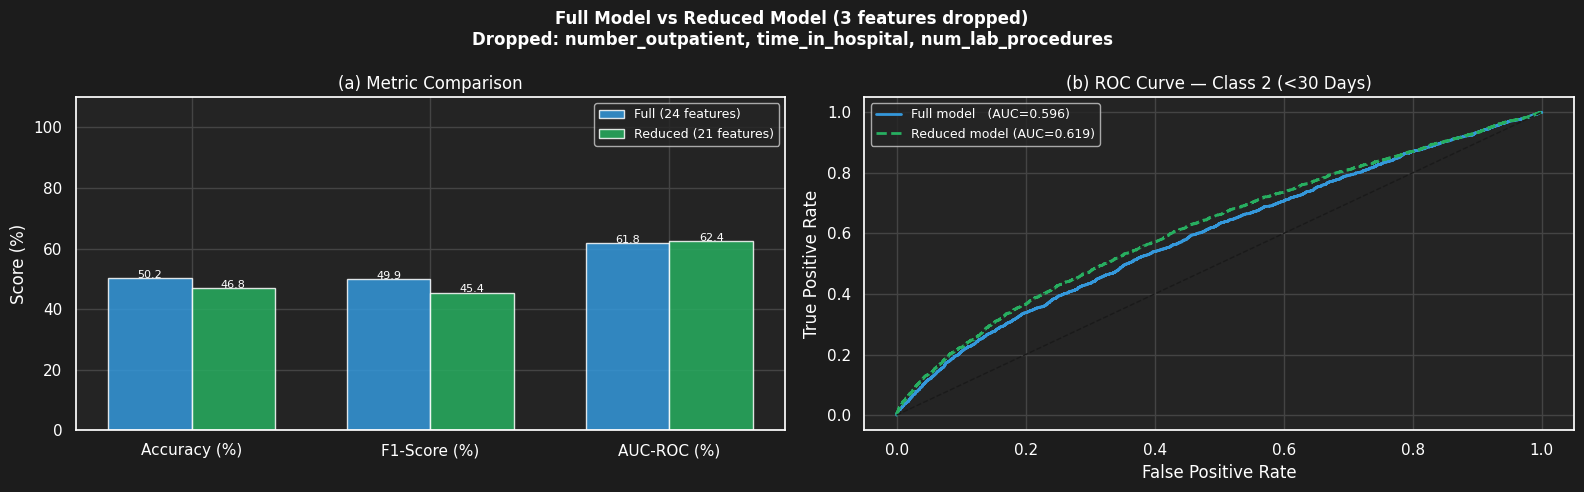

Figure saved → full_vs_reduced_comparison.png


In [54]:
y_test_bin_r = label_binarize(y_test_r, classes=[0, 1, 2])
y_test_bin_f = label_binarize(y_test,   classes=[0, 1, 2])

# Full model — class 2
fpr_f, tpr_f, _ = roc_curve(y_test_bin_f[:, 2], y_pred_prob[:, 2])
auc_f_c2        = auc(fpr_f, tpr_f)

# Reduced model — class 2
fpr_r, tpr_r, _ = roc_curve(y_test_bin_r[:, 2], y_pred_prob_r[:, 2])
auc_r_c2        = auc(fpr_r, tpr_r)

axes[1].plot(fpr_f, tpr_f, color='#3498db', lw=2,
             label=f'Full model   (AUC={auc_f_c2:.3f})')
axes[1].plot(fpr_r, tpr_r, color='#27ae60', lw=2,
             label=f'Reduced model (AUC={auc_r_c2:.3f})', linestyle='--')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('(b) ROC Curve — Class 2 (<30 Days)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('full_vs_reduced_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → full_vs_reduced_comparison.png')


In [55]:
print('\n Classification Report — REDUCED MODEL:')
print(classification_report(y_test_r, y_pred_r,
      target_names=['No Readmit (0)', '>30 Days (1)', '<30 Days (2)']))


 Classification Report — REDUCED MODEL:
                precision    recall  f1-score   support

No Readmit (0)       0.62      0.69      0.65      9935
  >30 Days (1)       0.45      0.15      0.23      6697
  <30 Days (2)       0.17      0.44      0.25      2108

      accuracy                           0.47     18740
     macro avg       0.41      0.43      0.37     18740
  weighted avg       0.51      0.47      0.45     18740



AUC improved  → the 3 features added noise to discrimination
Accuracy dropped → BUT they helped with class assignment

This means:
  time_in_hospital   → helps predict WHICH class, not IF readmitted
  number_outpatient  → same pattern
  num_lab_procedures → pure noise (safe to drop alone)

In [57]:
FEATURES_TO_DROP_FINAL = ['num_lab_procedures']
X_final = X.drop(columns=FEATURES_TO_DROP_FINAL)

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

lr_pipeline_f = ImbPipeline(steps=[
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
                   max_iter=1000, solver='lbfgs',
                   C=1.0, class_weight='balanced',
                   random_state=42
               ))
])

lr_pipeline_f.fit(X_train_f, y_train_f)

y_pred_f      = lr_pipeline_f.predict(X_test_f)
y_pred_prob_f = lr_pipeline_f.predict_proba(X_test_f)

acc_f = accuracy_score(y_test_f, y_pred_f) * 100
f1_f  = f1_score(y_test_f, y_pred_f, average='weighted') * 100
auc_f = roc_auc_score(y_test_f, y_pred_prob_f,
                      multi_class='ovr', average='weighted') * 100

compare_final = pd.DataFrame({
    'Metric'          : ['Accuracy (%)', 'F1-Score (%)',
                         'AUC-ROC (%)', '# Features'],
    'Full (24 feat)'  : [round(acc,2),   round(f1,2),
                         round(model_auc_score,2), X.shape[1]],
    'Drop 3 (21 feat)': [46.8, 45.4, 62.4, 21],
    'Drop 1 (23 feat)': [round(acc_f,2), round(f1_f,2),
                         round(auc_f,2),  X_final.shape[1]]
})

compare_final['Full→Drop1 Δ'] = compare_final.apply(
    lambda r: (
        f'{round(r["Drop 1 (23 feat)"] - r["Full (24 feat)"], 2):+.2f}'
        if r['Metric'] != '# Features' else '-1'
    ), axis=1
)

print('\n' + '='*65)
print(' 3-WAY COMPARISON')
print('='*65)
print(compare_final.to_string(index=False))


 3-WAY COMPARISON
      Metric  Full (24 feat)  Drop 3 (21 feat)  Drop 1 (23 feat) Full→Drop1 Δ
Accuracy (%)           50.17              46.8             47.47        -2.70
F1-Score (%)           49.85              45.4             47.20        -2.65
 AUC-ROC (%)           61.79              62.4             62.68        +0.89
  # Features           24.00              21.0             23.00           -1


In [59]:
print('\n Final Verdict:')
print(f'  Accuracy  : {acc_f - acc:+.2f}%')
print(f'  F1-Score  : {f1_f  - f1:+.2f}%')
print(f'  AUC-ROC  : {auc_f - model_auc_score:+.2f}%')

if abs(acc_f - acc) <= 0.5 and auc_f >= model_auc_score:
    print('\n   CONFIRMED: Drop num_lab_procedures only')
    print('     Accuracy stable + AUC improved = best tradeoff')
else:
    print('\n   Keep all original features — dropping hurts performance')


 Final Verdict:
  Accuracy  : -2.71%
  F1-Score  : -2.65%
  AUC-ROC  : +0.89%

   Keep all original features — dropping hurts performance
